In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import gensim



data_set = pd.read_csv('VKM_dataset.csv')

data_set.head(50)

,id,name,shortdescription,description,content,studycredit,location,contact_id,level,learningoutcomes,Rood,Groen,Blauw,Geel,module_tags,interests_match_score,popularity_score,estimated_difficulty,available_spots,start_date
0,159,Kennismaking met Psychologie,"Brein, gedragsbeinvloeding, ontwikkelingspsych...",In deze module leer je hoe je gedrag van jezel...,In deze module leer je hoe je gedrag van jezel...,15,Den Bosch,58,NLQF5,A. Je beantwoordt vragen in een meerkeuze kenn...,4.0,2.0,1.0,5.0,"['brein', 'gedragsbeinvloeding', 'ontwikkeling...",0.54,319,1,79,2025-12-24
1,160,Learning and working abroad,"Internationaal, persoonlijke ontwikkeling, ver...",Studenten kiezen binnen de (stam) van de oplei...,Studenten kiezen binnen de (stam) van de oplei...,15,Den Bosch,58,NLQF5,De student toont professioneel gedrag conform ...,5.0,3.0,1.0,1.0,"['internationaal', 'persoonlijke', 'ontwikkeli...",0.92,172,5,56,2025-12-20
2,161,Proactieve zorgplanning,"Proactieve zorgplanning, cocreatie, ziekenhuis",Het Jeroen Bosch ziekenhuis wil graag samen me...,Het Jeroen Bosch ziekenhuis wil graag samen me...,15,Den Bosch,59,NLQF5,De student past pro actieve zorgplanning toe b...,NaN,NaN,NaN,NaN,"['proactieve', 'zorgplanning', 'cocreatie', 'z...",0.78,217,5,55,2025-09-23
3,162,Rouw en verlies,"Rouw & verlies, palliatieve zorg & redeneren, ...",In deze module wordt stil gestaan bij rouw en ...,In deze module wordt stil gestaan bij rouw en ...,30,Den Bosch,58,NLQF6,De student regisseert en voert (deels) zelfsta...,NaN,NaN,NaN,NaN,"['rouw', 'verlies', 'palliatieve', 'zorg', 're...",0.69,454,1,54,2025-10-25
4,163,Acuut complexe zorg,"Acute zorg, complexiteit, ziekenhuis, revalidatie",In deze module kunnen studenten zich verdiepen...,In deze module kunnen studenten zich verdiepen...,30,Den Bosch,58,NLQF6,De student regisseert en voert (deels) zelfsta...,NaN,NaN,NaN,NaN,"['acute', 'zorg', 'complexiteit', 'ziekenhuis'...",0.40,178,5,38,2025-11-19
5,164,Kraam kind en jeugd,"Jeugdzorg, neonatologie, verloskunde, kindzorg",In deze module kunnen studenten zich verdiepen...,In deze module kunnen studenten zich verdiepen...,30,Den Bosch,58,NLQF6,De student regisseert en voert (deels) zelfsta...,NaN,NaN,NaN,NaN,"['jeugdzorg', 'neonatologie', 'verloskunde', '...",0.40,493,5,39,2025-12-04
6,165,Profiel specifieke modulen Welzijn & Samenlevi...,"Jeugdzorg, geestelijke gezondheidzorg, rechtva...",Profiel specifieke modulen Welzijn & Samenlevi...,Profiel specifieke modulen Welzijn & Samenlevi...,15,Breda en Den Bosch,58,NLQF5,Nader te bepalen,NaN,NaN,NaN,NaN,"['jeugdzorg', 'geestelijke', 'gezondheidzorg',...",0.34,170,5,76,2025-11-14
7,166,"Happy city, happy people design lab","vitale gemeenschappen, duurzaam gebouwde omgev...",focus op de grote vraagstukken (SDG gestuurd) ...,focus op de grote vraagstukken (SDG gestuurd) ...,15,Den Bosch,58,NLQF5,Nader te bepalen,NaN,NaN,NaN,NaN,"['vitale', 'gemeenschappen', 'duurzaam', 'gebo...",0.86,77,3,37,2025-12-27
8,167,Building & Sustaining vital communities,"vitale gemeenschappen, duurzaam gebouwde omgev...",Je bedenkt en ontwerpt samen met relevante sta...,Je bedenkt en ontwerpt samen met relevante sta...,30,Den Bosch,58,NLQF6,Nader te bepalen,NaN,NaN,NaN,NaN,"['vitale', 'gemeenschappen', 'duurzaam', 'gebo...",0.69,298,4,66,2025-09-16
9,168,GGZ Agoog,"Herstel en krachtgericht werk, leven met psych...","Je bent 'state of the art' in kennis, handelin...","Je bent 'state of the art' in kennis, handelin...",30,Den Bosch,58,NLQF6,Toetsvormen zijn afgeleide van beroepsprestati...,NaN,NaN,NaN,NaN,"['herstel', 'en', 'krachtgericht', 'werk', 'le...",0.76,407,2,60,2025-09-08


In [3]:
data_set_copy = data_set.copy()

for column in data_set_copy.columns:
    print(f'Column: {column}, Missing values: {data_set_copy[column].isnull().sum()}')

Column: id, Missing values: 0
Column: name, Missing values: 0
Column: shortdescription, Missing values: 20
Column: description, Missing values: 0
Column: content, Missing values: 0
Column: studycredit, Missing values: 0
Column: location, Missing values: 0
Column: contact_id, Missing values: 0
Column: level, Missing values: 0
Column: learningoutcomes, Missing values: 5
Column: Rood, Missing values: 209
Column: Groen, Missing values: 209
Column: Blauw, Missing values: 209
Column: Geel, Missing values: 209
Column: module_tags, Missing values: 0
Column: interests_match_score, Missing values: 0
Column: popularity_score, Missing values: 0
Column: estimated_difficulty, Missing values: 0
Column: available_spots, Missing values: 0
Column: start_date, Missing values: 0


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import gensim



data_set = pd.read_csv('VKM_dataset.csv')

data_set.head()

,id,name,shortdescription,description,content,studycredit,location,contact_id,level,learningoutcomes,Rood,Groen,Blauw,Geel,module_tags,interests_match_score,popularity_score,estimated_difficulty,available_spots,start_date
0,159,Kennismaking met Psychologie,"Brein, gedragsbeinvloeding, ontwikkelingspsych...",In deze module leer je hoe je gedrag van jezel...,In deze module leer je hoe je gedrag van jezel...,15,Den Bosch,58,NLQF5,A. Je beantwoordt vragen in een meerkeuze kenn...,4.0,2.0,1.0,5.0,"['brein', 'gedragsbeinvloeding', 'ontwikkeling...",0.54,319,1,79,2025-12-24
1,160,Learning and working abroad,"Internationaal, persoonlijke ontwikkeling, ver...",Studenten kiezen binnen de (stam) van de oplei...,Studenten kiezen binnen de (stam) van de oplei...,15,Den Bosch,58,NLQF5,De student toont professioneel gedrag conform ...,5.0,3.0,1.0,1.0,"['internationaal', 'persoonlijke', 'ontwikkeli...",0.92,172,5,56,2025-12-20
2,161,Proactieve zorgplanning,"Proactieve zorgplanning, cocreatie, ziekenhuis",Het Jeroen Bosch ziekenhuis wil graag samen me...,Het Jeroen Bosch ziekenhuis wil graag samen me...,15,Den Bosch,59,NLQF5,De student past pro actieve zorgplanning toe b...,NaN,NaN,NaN,NaN,"['proactieve', 'zorgplanning', 'cocreatie', 'z...",0.78,217,5,55,2025-09-23
3,162,Rouw en verlies,"Rouw & verlies, palliatieve zorg & redeneren, ...",In deze module wordt stil gestaan bij rouw en ...,In deze module wordt stil gestaan bij rouw en ...,30,Den Bosch,58,NLQF6,De student regisseert en voert (deels) zelfsta...,NaN,NaN,NaN,NaN,"['rouw', 'verlies', 'palliatieve', 'zorg', 're...",0.69,454,1,54,2025-10-25
4,163,Acuut complexe zorg,"Acute zorg, complexiteit, ziekenhuis, revalidatie",In deze module kunnen studenten zich verdiepen...,In deze module kunnen studenten zich verdiepen...,30,Den Bosch,58,NLQF6,De student regisseert en voert (deels) zelfsta...,NaN,NaN,NaN,NaN,"['acute', 'zorg', 'complexiteit', 'ziekenhuis'...",0.40,178,5,38,2025-11-19


In [5]:
data_set_copy = data_set.copy()

for column in data_set_copy.columns:
    print(f'Column: {column}, Missing values: {data_set_copy[column].isnull().sum()}')

Column: id, Missing values: 0
Column: name, Missing values: 0
Column: shortdescription, Missing values: 20
Column: description, Missing values: 0
Column: content, Missing values: 0
Column: studycredit, Missing values: 0
Column: location, Missing values: 0
Column: contact_id, Missing values: 0
Column: level, Missing values: 0
Column: learningoutcomes, Missing values: 5
Column: Rood, Missing values: 209
Column: Groen, Missing values: 209
Column: Blauw, Missing values: 209
Column: Geel, Missing values: 209
Column: module_tags, Missing values: 0
Column: interests_match_score, Missing values: 0
Column: popularity_score, Missing values: 0
Column: estimated_difficulty, Missing values: 0
Column: available_spots, Missing values: 0
Column: start_date, Missing values: 0


In [6]:
data_set_copy.head()

,id,name,shortdescription,description,content,studycredit,location,contact_id,level,learningoutcomes,Rood,Groen,Blauw,Geel,module_tags,interests_match_score,popularity_score,estimated_difficulty,available_spots,start_date
0,159,Kennismaking met Psychologie,"Brein, gedragsbeinvloeding, ontwikkelingspsych...",In deze module leer je hoe je gedrag van jezel...,In deze module leer je hoe je gedrag van jezel...,15,Den Bosch,58,NLQF5,A. Je beantwoordt vragen in een meerkeuze kenn...,4.0,2.0,1.0,5.0,"['brein', 'gedragsbeinvloeding', 'ontwikkeling...",0.54,319,1,79,2025-12-24
1,160,Learning and working abroad,"Internationaal, persoonlijke ontwikkeling, ver...",Studenten kiezen binnen de (stam) van de oplei...,Studenten kiezen binnen de (stam) van de oplei...,15,Den Bosch,58,NLQF5,De student toont professioneel gedrag conform ...,5.0,3.0,1.0,1.0,"['internationaal', 'persoonlijke', 'ontwikkeli...",0.92,172,5,56,2025-12-20
2,161,Proactieve zorgplanning,"Proactieve zorgplanning, cocreatie, ziekenhuis",Het Jeroen Bosch ziekenhuis wil graag samen me...,Het Jeroen Bosch ziekenhuis wil graag samen me...,15,Den Bosch,59,NLQF5,De student past pro actieve zorgplanning toe b...,NaN,NaN,NaN,NaN,"['proactieve', 'zorgplanning', 'cocreatie', 'z...",0.78,217,5,55,2025-09-23
3,162,Rouw en verlies,"Rouw & verlies, palliatieve zorg & redeneren, ...",In deze module wordt stil gestaan bij rouw en ...,In deze module wordt stil gestaan bij rouw en ...,30,Den Bosch,58,NLQF6,De student regisseert en voert (deels) zelfsta...,NaN,NaN,NaN,NaN,"['rouw', 'verlies', 'palliatieve', 'zorg', 're...",0.69,454,1,54,2025-10-25
4,163,Acuut complexe zorg,"Acute zorg, complexiteit, ziekenhuis, revalidatie",In deze module kunnen studenten zich verdiepen...,In deze module kunnen studenten zich verdiepen...,30,Den Bosch,58,NLQF6,De student regisseert en voert (deels) zelfsta...,NaN,NaN,NaN,NaN,"['acute', 'zorg', 'complexiteit', 'ziekenhuis'...",0.40,178,5,38,2025-11-19


In [7]:
# kijken naar specifieke 'ntb' waarden in kolommen
columns_to_check = ['shortdescription', 'description', 'content', 'level', 'learningoutcomes']

for col in columns_to_check:
    count = (data_set_copy[col].str.lower() == 'ntb').sum()
    print(f"{col}: {count} keer 'ntb'")

na_count = data_set_copy['studycredit'].isna().sum()
print(f"studycredit: {na_count} missing values")

tags_count = (data_set_copy['module_tags'].str.lower() == "['ntb']").sum()
print(f"module_tags: {tags_count} keer ['ntb']")


shortdescription: 10 keer 'ntb'
description: 2 keer 'ntb'
content: 2 keer 'ntb'
level: 0 keer 'ntb'
learningoutcomes: 26 keer 'ntb'
studycredit: 0 missing values
module_tags: 10 keer ['ntb']


# Data-opschonen

In [8]:
# Het opschonen van de dataset begint hier

# De volgende kolommen heb ik niet nodig voor mijn analyse. Het bevat te weinig informatie waardoor ik niet veel heb aan deze data.
columns_to_drop = ['Rood', 'Geel', 'Groen', 'Blauw']
if all(col in data_set_copy.columns for col in columns_to_drop):
    data_set_copy.drop(columns=columns_to_drop, inplace=True)

# Vervangen van 'ntb', 'Ntb' en "['ntb']" met NaN waardes, zodat deze als missende waardes worden herkend en consistent zijn door de dataset heen.
data_set_copy.replace('ntb', np.nan, inplace=True)
data_set_copy.replace('Ntb', np.nan, inplace=True)
data_set_copy.replace("['ntb']", np.nan, inplace=True)

# Vervangen van waarden die niet compleet zijn met NaN waardes, zodat deze als missende waardes worden herkend en consistent zijn door de dataset heen.
data_set_copy.replace('Nog niet bekend', np.nan, inplace=True)
data_set_copy.replace('nog niet bekend', np.nan, inplace=True)
data_set_copy.replace("Nader te bepalen", np.nan, inplace=True)
data_set_copy.replace("n.n.b.", np.nan, inplace=True)
data_set_copy.replace("Nog nader te bepalen", np.nan, inplace=True)
data_set_copy.replace("Nog te formuleren", np.nan, inplace=True)

# Hier wordt de waarden van de kolom 'start_date' omgezet naar datetime objecten. Foutieve data wordt omgezet naar NaT (Not a Time).
data_set_copy['start_date'] = data_set_copy['start_date'] = pd.to_datetime(data_set_copy['start_date'], errors='coerce')
# Er zijn waarden in de kolom 'module_tags' die speciale karakters bevatten zoals [ ]'. Deze heb ik verwijderd zodat de tags beter leesbaar zijn en consistent zijn.
data_set_copy['module_tags'] = data_set_copy['module_tags'].str.replace(r"[\[\]']", '', regex=True)
# Voor de kolom 'shortdescription' worden de missende waardes ingevuld met de eerste zin van de kolom 'description'.
data_set_copy['shortdescription'] = data_set_copy['shortdescription'].fillna(data_set_copy['description'].str.split('.').str[0])
# Voor de kolom 'description' worden de missende waardes ingevuld met de eerste zin van de kolom 'shortdescription'.
data_set_copy['description'] = data_set_copy['description'].fillna(data_set_copy['shortdescription'].str.split('.').str[0])
# Voor de kolom 'content' worden de missende waardes ingevuld met de eerste zin van de kolom 'description'.
data_set_copy['content'] = data_set_copy['content'].fillna(data_set_copy['description'].str.split('.').str[0])

# Alle tekstkolommen worden omgezet naar kleine letters en ontdaan van leger ruimtes aan het begin en einde van de tekst.
data_set_copy['shortdescription'] = data_set_copy['shortdescription'].str.lower().str.strip()
data_set_copy['description'] = data_set_copy['description'].str.lower().str.strip()
data_set_copy['content'] = data_set_copy['content'].str.lower().str.strip()
data_set_copy['learningoutcomes'] = data_set_copy['learningoutcomes'].str.lower().str.strip()
data_set_copy['name'] = data_set_copy['name'].str.lower().str.strip()

# dubbele rijen verwijderen uit de dataset als deze er zijn om de analyse niet te verstoren.
data_set_copy.drop_duplicates(inplace=True)

data_set_copy.reset_index(drop=True, inplace=True)

# Nieuwe kolom 'status' toevoegen die aangeeft of de module definitief is of voorlopig op basis van missende waardes.
data_set_copy['status'] = np.where(data_set_copy.isna().any(axis=1), 'voorlopig', 'definitief')

data_set_copy.to_csv('VKM_dataset_cleaned.csv', index=False)

data_set_copy.head()


# data_set_copy.to_csv('VKM_dataset_cleaned.csv', index=False)

,id,name,shortdescription,description,content,studycredit,location,contact_id,level,learningoutcomes,module_tags,interests_match_score,popularity_score,estimated_difficulty,available_spots,start_date,status
0,159,kennismaking met psychologie,"brein, gedragsbeinvloeding, ontwikkelingspsych...",in deze module leer je hoe je gedrag van jezel...,in deze module leer je hoe je gedrag van jezel...,15,Den Bosch,58,NLQF5,a. je beantwoordt vragen in een meerkeuze kenn...,"brein, gedragsbeinvloeding, ontwikkelingspsych...",0.54,319,1,79,2025-12-24,definitief
1,160,learning and working abroad,"internationaal, persoonlijke ontwikkeling, ver...",studenten kiezen binnen de (stam) van de oplei...,studenten kiezen binnen de (stam) van de oplei...,15,Den Bosch,58,NLQF5,de student toont professioneel gedrag conform ...,"internationaal, persoonlijke, ontwikkeling, ve...",0.92,172,5,56,2025-12-20,definitief
2,161,proactieve zorgplanning,"proactieve zorgplanning, cocreatie, ziekenhuis",het jeroen bosch ziekenhuis wil graag samen me...,het jeroen bosch ziekenhuis wil graag samen me...,15,Den Bosch,59,NLQF5,de student past pro actieve zorgplanning toe b...,"proactieve, zorgplanning, cocreatie, ziekenhuis",0.78,217,5,55,2025-09-23,definitief
3,162,rouw en verlies,"rouw & verlies, palliatieve zorg & redeneren, ...",in deze module wordt stil gestaan bij rouw en ...,in deze module wordt stil gestaan bij rouw en ...,30,Den Bosch,58,NLQF6,de student regisseert en voert (deels) zelfsta...,"rouw, verlies, palliatieve, zorg, redeneren, t...",0.69,454,1,54,2025-10-25,definitief
4,163,acuut complexe zorg,"acute zorg, complexiteit, ziekenhuis, revalidatie",in deze module kunnen studenten zich verdiepen...,in deze module kunnen studenten zich verdiepen...,30,Den Bosch,58,NLQF6,de student regisseert en voert (deels) zelfsta...,"acute, zorg, complexiteit, ziekenhuis, revalid...",0.40,178,5,38,2025-11-19,definitief


<Axes: >

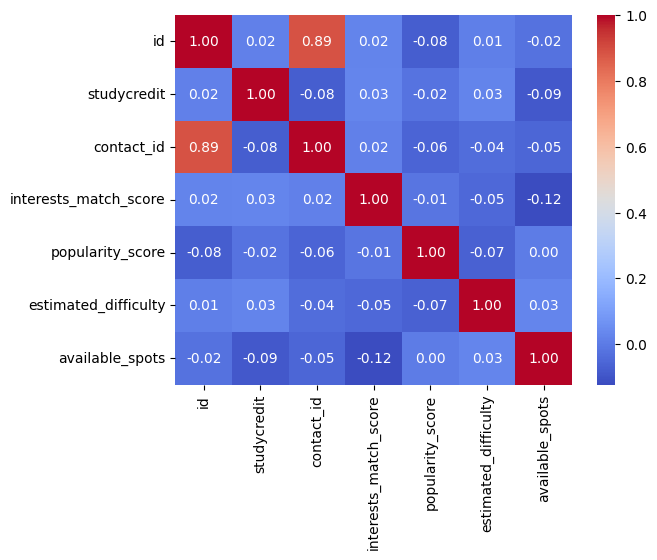

In [9]:
sns.heatmap(data_set_copy.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")

In [10]:
from keybert import KeyBERT

kw_model = KeyBERT()
moduleTags = []
#datafilteren
datacopy = data_set_copy.copy()
voorlopige_modules = datacopy[datacopy['status'] == 'voorlopig']
#voorlopige_modules.head()

#alle nan values module_tags krijgen
nan_module_tags = voorlopige_modules[voorlopige_modules['module_tags'].isna()]
# nan_module_tags.head(50)

# loopen door de dataset en de description eruit halen en daarna keybert gebruiken om tags te maken die toegevoegd wordt aan module_tags
for index, row in nan_module_tags.iterrows():
    text = row['description']
    keywords = kw_model.extract_keywords(text, stop_words='dutch', top_n=2, keyphrase_ngram_range=(1,1))
    tags = [kw[0] for kw in keywords]
    moduleTags.append(tags)


# nan_module_tags.loc[nan_module_tags['module_tags'].isnull(), 'module_tags'] = moduleTags

print(keywords)







c:\documenten\LU2-AI-Prototype\AI-PoC\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


[]


In [11]:
from keybert import KeyBERT

doc = """
         Supervised learning is the machine learning task of learning a function that
         maps an input to an output based on example input-output pairs. It infers a
         function from labeled training data consisting of a set of training examples.
         In supervised learning, each example is a pair consisting of an input object
         (typically a vector) and a desired output value (also called the supervisory signal).
         A supervised learning algorithm analyzes the training data and produces an inferred function,
         which can be used for mapping new examples. An optimal scenario will allow for the
         algorithm to correctly determine the class labels for unseen instances. This requires
         the learning algorithm to generalize from the training data to unseen situations in a
         'reasonable' way (see inductive bias).
      """
kw_model = KeyBERT()
keywords = kw_model.extract_keywords(doc, top_n=2)
print(keywords)

[('supervised', 0.6676), ('labeled', 0.4896)]
